### 1. Multispectral Data Acquisition and Feature Engineering

El objetivo de este apartado es la construcción de un dataset mediante la librería **MapMiner**, transformando datos satelitales en indicadores biológicos aptos para el modelado.  

**Estrategia de Muestreo con MapMiner:**  
- ¿Cómo se ha definido la selección de zonas a nivel global?
- ¿De qué manera MapMiner permite pasar de un análisis local a uno de alcance forestal y agrícola a gran escala? 

**Control de Calidad:**   
- ¿Cuál es la condición de descarte de datos para asegurar que el dataset final esté libre de ruido atmosférico?
- ¿En qué criterio se basa esta detección?

**Ingeniería de Características:**
- ¿Cómo se aprovechan los datos del infrarrojo extraídos por MapMiner para detectar anomalías que el ojo humano ignora?
- ¿Por qué se calcula la media y la desviación estándar de cada banda en lugar de usar píxeles individuales?

In [19]:
import os
import numpy as np
import pandas as pd
from mapminer.miners import LandsatMiner
import time

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE 

In [2]:
inici = time.time()
# ==========================================
# 1. CREACIÓN DE CARPETA
# ==========================================
base_dir = os.path.join("..", "data")
os.makedirs(base_dir, exist_ok=True)

# ==========================================
# 2. BASE DE DATOS 
# ==========================================
def fabricar_puntos(nombre, estado, lat, lon, dispersion, n, fecha):
    lats = np.random.uniform(lat - dispersion, lat + dispersion, n)
    lons = np.random.uniform(lon - dispersion, lon + dispersion, n)
    return [{"id": f"{nombre}_{i}", "lat": lats[i], "lon": lons[i], "estado": estado, "rango": fecha} for i in range(n)]

dataset = []

# SANO (600 puntos)  
dataset += fabricar_puntos("Iowa_USA", "sano", 41.55, -93.60, 0.5, 200, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Po_Italia", "sano", 45.00, 10.00, 0.3, 200, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Mekong_Vietnam", "sano", 10.50, 105.10, 0.2, 200, "2024-05-01/2024-05-15")

# SEQUÍA CRÓNICA (600 puntos)  
dataset += fabricar_puntos("Andalucia_ESP", "enfermo_sequia", 37.55, -5.50, 0.4, 200, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Chaco_ARG", "enfermo_sequia", -25.00, -60.00, 0.4, 200, "2024-01-01/2024-01-15")
dataset += fabricar_puntos("Outback_AUS", "enfermo_sequia", -32.00, 148.00, 0.5, 200, "2023-12-01/2023-12-15")

# PLAGAS Y ENFERMEDADES BIÓTICAS (600 puntos) 
dataset += fabricar_puntos("Schwarzwald_GER", "enfermo_plaga", 48.00, 8.20, 0.3, 200, "2023-07-15/2023-07-30")
dataset += fabricar_puntos("Soria_ESP", "enfermo_plaga", 41.76, -2.46, 0.2, 200, "2024-06-20/2024-07-05")
dataset += fabricar_puntos("British_Columbia_CAN", "enfermo_plaga", 53.00, -123.00, 0.4, 200, "2023-08-01/2023-08-15")

# INCENDIO / HUMO (800 puntos)  
dataset += fabricar_puntos("Amazonas_BR", "incendio", -10.00, -60.00, 0.5, 200, "2024-08-01/2024-08-15")
dataset += fabricar_puntos("Alberta_CAN", "incendio", 55.00, -115.00, 0.5, 200, "2023-06-01/2023-06-15")
dataset += fabricar_puntos("California_USA", "incendio", 37.00, -120.00, 0.4, 200, "2024-09-01/2024-09-15")
dataset += fabricar_puntos("Valparaiso_CHL", "incendio", -33.10, -71.50, 0.2, 200, "2024-02-01/2024-02-15")

# ESTRÉS TÉRMICO / CALOR EXTREMO (400 puntos) 
dataset += fabricar_puntos("Texas_USA", "enfermo_estres", 33.50, -101.80, 0.4, 200, "2023-07-01/2023-07-15")
dataset += fabricar_puntos("Argelia_Sahara", "enfermo_estres", 34.80, 5.70, 0.3, 200, "2023-08-01/2023-08-15")

# EXCESO HÍDRICO / INUNDACIÓN (400 puntos)
# Estrés por asfixia radicular (anoxia) debido a inundaciones
dataset += fabricar_puntos("Rio_Grande_Sul_BR", "estres_inundacion", -30.00, -51.50, 0.5, 200, "2024-05-15/2024-05-30")
dataset += fabricar_puntos("Queensland_AUS", "estres_inundacion", -18.00, 145.00, 0.4, 200, "2024-02-15/2024-02-28")

# DEFORESTACIÓN / TALA (400 puntos) 
dataset += fabricar_puntos("Rondonia_BR", "deforestacion", -10.50, -63.00, 0.4, 200, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Borneo_IDN", "deforestacion", -1.00, 114.00, 0.5, 200, "2024-06-01/2024-06-15")

# ==========================================
# 3. BUCLE DE PROCESAMIENTO (Vigilando Nubes/Humo)
# ==========================================
miner = LandsatMiner()
bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
resultados = []

print(f" Iniciando búsqueda de {len(dataset)} puntos...")

for i, p in enumerate(dataset):
    inici_p = time.time()
    try:
        ds = miner.fetch(lat=p['lat'], lon=p['lon'], radius=600, daterange=p['rango'])
        ds_single = ds[bandas].isel(time=0)
        
        # FILTRO ANTI-NUBES 
        # Si el rojo es muy brillante (>35k) + azul es sospechosamente alto --> es una nube blanca 
        red_m = ds_single.red.mean().values
        blue_m = ds_single.blue.mean().values
        
        if red_m > 36000 or blue_m > 30000:
            continue 

        # Estadísticas para el ML
        df_pix = ds_single.to_dataframe().reset_index().dropna(subset=bandas)
        if df_pix.empty: continue
 
        # NDVI: (NIR - RED) / (NIR + RED)
        df_pix['ndvi'] = (df_pix['nir08'] - df_pix['red']) / (df_pix['nir08'] + df_pix['red'])
        
        # GNDVI: (NIR - GREEN) / (NIR + GREEN)
        df_pix['gndvi'] = (df_pix['nir08'] - df_pix['green']) / (df_pix['nir08'] + df_pix['green'])

        columnas_analisis = bandas + ['ndvi', 'gndvi']
        stats = df_pix[columnas_analisis].agg(['mean', 'std'])
        
        stats_fila = stats.unstack().to_frame().T
        stats_fila.columns = [f"{b}_{s}" for b, s in stats_fila.columns]
         
        stats_fila['id_campo'] = p['id']
        stats_fila['estado'] = p['estado']
        stats_fila['lat'] = p['lat']
        stats_fila['lon'] = p['lon']
        
        resultados.append(stats_fila)
        
        fi_p = time.time()
        temps_p = fi_p - inici_p
        
        if (i+1) % 50 == 0:
            print(f" Procesados {i+1}/{len(dataset)}... Llevamos {len(resultados)} válidos. Este bloque tardó: {temps_p:.2f}s por punto")

    except Exception:
        continue

# ==========================================
# 4. GUARDAR DATASET FINAL CSV
# ==========================================
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    
    cols = ['id_campo', 'estado'] + [c for c in df_final.columns if c not in ['id_campo', 'estado']]
    df_final = df_final[cols]
    
    ruta = os.path.join(base_dir, "dataset.csv")
    df_final.to_csv(ruta, index=False)

    fi = time.time()
    temps = (fi - inici) / 60
    
    print(f"\n ¡FIN + FINALIZADO EN {temps:.2f} MINUTOS!! Dataset de {len(df_final)} líneas guardado en: {ruta}")
else:
    print("Algo ha salido mal, no hemos podido rescatar datos.")

 Iniciando búsqueda de 3800 puntos...
 Procesados 50/3800... Llevamos 47 válidos. Este bloque tardó: 0.92s por punto
 Procesados 100/3800... Llevamos 97 válidos. Este bloque tardó: 0.17s por punto
 Procesados 150/3800... Llevamos 144 válidos. Este bloque tardó: 0.56s por punto
 Procesados 200/3800... Llevamos 193 válidos. Este bloque tardó: 0.84s por punto
 Procesados 250/3800... Llevamos 237 válidos. Este bloque tardó: 0.65s por punto
 Procesados 300/3800... Llevamos 284 válidos. Este bloque tardó: 0.61s por punto
 Procesados 350/3800... Llevamos 330 válidos. Este bloque tardó: 0.68s por punto
 Procesados 400/3800... Llevamos 377 válidos. Este bloque tardó: 0.74s por punto
 Procesados 450/3800... Llevamos 427 válidos. Este bloque tardó: 1.06s por punto
 Procesados 500/3800... Llevamos 477 válidos. Este bloque tardó: 0.16s por punto
 Procesados 550/3800... Llevamos 527 válidos. Este bloque tardó: 0.75s por punto
 Procesados 600/3800... Llevamos 577 válidos. Este bloque tardó: 1.15s por

In [5]:
print("\n---------------------------------------------")
print("---- ESTRATEGIA DE MUESTREO CON MAPMINER ----")
print("---------------------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("Para la construcción del Dataset, hemos seleccionado 19 regiones geográficas distribuidas globalmente para cubrir en todo lo posible, un espectro completo de salud vegetal.")
print("Nuestro criterio se basa en identificar biomas especificos donde hayan ocurrido fenómenos de estudio, y de esta manera permitiendo al modelo aprender diferentes enfermedades.")

print("\nCategorías de estudio y distribución:")
print("  1. Sano: Bosques con vigor óptimo y sin anomalías espectrales.")
print("  2. Sequía Crónica: Estrés por déficit hídrico prolongado.")
print("  3. Plagas y Enfermedades Bióticas: Daño por insectos (barrenadores) u hongos (ej. Phytophthora).")
print("  4. Incendio y Humo: Áreas con fuego activo o degradación post-incendio.")
print("  5. Estrés Térmico: Marchitamiento rápido por temperaturas récord (Cúpula de calor).")
print("  6. Exceso Hídrico y Inundación: Estrés por asfixia radicular (anoxia) debido a inundaciones.")
print("  7. Deforestación y Tala: Cambio radical de uso de suelo (pérdida total de vegetación).")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("MapMiner es una potente herramienta diseñada para extraer y procesar de forma eficiente datos geoespaciales de diversas fuentes.")
print("- A diferencia de un análisis local manual, Mapminer permite desacoplar la búsqueda de coordenadas y llegando a usar funciones para una generación de puntos, es decir, el poder muestrear miles de localizaciones en biomas distintos en una misma ejecución.")
print("- La herramienta normaliza la ingesta de bandas críticas (NIR, SWIR, RGB). Esto permite que el modelo aprenda de la firma espectral universal de una patologia vegetal.")
print("- MapMiner no descarga imágenes pesadas innecesariamente, sino que aplica una reducción de dimensionalidad convirtiendo millones de píxeles en estadísticas de zona (media y desviación estándar), resultando un coste computacional mínimo.")


print("\n----------------------------")
print("---- CONTROL DE CALIDAD ----")
print("----------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("Para garantizar que el dataset esté libre de ruido atmosférico, hemos implementado una condición de descarte automatizada basada en la reflectancia de las bandas visibles.")
print("Durante el bucle de procesamiento se aplica un threshold, si la media del canal Rojo supera las 36 000 unidades o el Azul supera las 30 000, entonces la muestra se omite automáticamente y asi eliminando picos de brillo excesivo para evitar falsos positivos debido a interferencias climáticas.")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("Se basa en la diferencia de ALBEDO (reflectancia). La vegetación sana o estresada absorbe gran parte de la luz visible para realizar la fotosíntesis, por lo que sus valores en las bandas Roja y Azul son naturalmente bajos.")
print("Pero las nubes y el humo denso actúan como espejos que reflejan casi toda la radiación solar de vuelta al satélite. Esto genera un ruido blanco que satura los sensores y asi impidiendo la lectura correcta de la superficie.")


print("\n---------------------------------------")
print("---- INGENIERIA DE CARACTERISTICAS ----")
print("---------------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("El ojo humano solo percibe el espectro visible (RGB), por lo que cuando nos encontramos con enfermedades y zonas que parece que está todo bien, puede llegar a ser que en realidad si que hay alguna enfermedad pero de manera invisible para nuestros ojos.")
print("\n- Detección invisible con NIR:")
print("Las plantas sanas reflejan casi todo el Infrarrojo Cercano (NIR) debido a su estructura celular. Cuando sufren estrés (plagas o sequía), esta estructura colapsa y el NIR cae drásticamente mucho antes de que la hoja cambie de color a simple vista, por lo que nos permite un diagnóstico precoz.")
print("\n- Sensibilidad al agua con SWIR:")
print("El Infrarrojo de Onda Corta (SWIR) es extremadamente sensible al contenido de agua. MapMiner nos permite extraer estas bandas para diferenciar entre una planta sana y una con estrés hídrico o identificar áreas quemadas incluso a través de la bruma.")
print("\n- Transformación en Índices Biológicos:")
print("No usamos solo datos brutos, sino que también calculamos el NDVI (vigor general) y el GNDVI (sensibilidad a la clorofila). Estos índices convierten los datos infrarrojos en ecuaciones matemáticas que permiten al modelo identificar caídas en la productividad biológica de forma cuantitativa y objetiva.")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("Un píxel individual puede contener errores de lectura (sombras o variaciones insignificantes).")
print("- Por un lado, al calcular la Media obtenemos la firma espectral representativa de toda la zona (radio de 600m), siendo unos datos más estables para el modelo de Deep Learning.")
print("- Por otro lado, la Desviación Estándar nos aporta información sobre la variabilidad del terreno, es decir, si es alta puede indicar que la enfermedad no es uniforme o que estamos en un borde de deforestación, dando información de textura del lugar al modelo que un solo píxel no podría proporcionar.")
print("Además, al transformar miles de píxeles en solo dos estadísticos por banda reduce la dimensionalidad del problema. Esto nos permite procesar miles de regiones globales de forma rápida y evitando overfitting, y además optimiza el rendimiento de la red neuronal.")



---------------------------------------------
---- ESTRATEGIA DE MUESTREO CON MAPMINER ----
---------------------------------------------

PRIMER PUNTO:
Para la construcción del Dataset, hemos seleccionado 19 regiones geográficas distribuidas globalmente para cubrir en todo lo posible, un espectro completo de salud vegetal.
Nuestro criterio se basa en identificar biomas especificos donde hayan ocurrido fenómenos de estudio, y de esta manera permitiendo al modelo aprender diferentes enfermedades.

Categorías de estudio y distribución:
  1. Sano: Bosques con vigor óptimo y sin anomalías espectrales.
  2. Sequía Crónica: Estrés por déficit hídrico prolongado.
  3. Plagas y Enfermedades Bióticas: Daño por insectos (barrenadores) u hongos (ej. Phytophthora).
  4. Incendio y Humo: Áreas con fuego activo o degradación post-incendio.
  5. Estrés Térmico: Marchitamiento rápido por temperaturas récord (Cúpula de calor).
  6. Exceso Hídrico y Inundación: Estrés por asfixia radicular (anoxia) deb

### 2. EDA (*Exploratory Data Analysis*) 

Antes de comenzar, es fundamental analizar la base de datos creada.  

**Entender el Dataset:**  
- ¿Cuál es el target? ¿Cuántas categorías distintas tiene?
- ¿Cuántos atributos existen? ¿Cuáles son?
- ¿Cuáles son numéricas? ¿Y categóricas?
- ¿Hay missing values?
- ¿Las etiquetas están balanceadas?
  
**Análisis Univariante:**

Por cada variable:
- ¿Cuál es su distribución?
- ¿Hay valores atípicos?
- ¿Es necesario escalar o transformar?

**Relación con el Target:**

¿El atributo varía según el target?
Entonces utilizar:
- groupby
- boxplots
- barplots
- scatterplots

**Análisis de Correlación:**
- ¿Qué atributos numéricos se correlacionan?
- ¿Existe alguna redundancia?

**Importancia de los Atributos:**

Pruebe un Random Forest simple o un Árbol de decisión:
- ¿Qué atributos importan más?

**Comprobación de Peligro:**
- ¿Podría alguna variable causar fecha leakage?
- ¿Tiene sentido la correlación a la vida real?

**Conclusiones:**
- ¿Qué 3 atributos parecen más predictivas?
- ¿Qué 3 parecen débiles o irrelevantes?

In [6]:
#Carregar el Dataset
df = pd.read_csv('../data/dataset.csv')
df.head()
df.info()
df.describe()
x_train, x_test, y_train, y_test = train_test_split(df.drop('estado', axis=1), df['estado'], test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3496 entries, 0 to 3495
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_campo     3496 non-null   object 
 1   estado       3496 non-null   object 
 2   red_mean     3496 non-null   float64
 3   red_std      3496 non-null   float64
 4   green_mean   3496 non-null   float64
 5   green_std    3496 non-null   float64
 6   blue_mean    3496 non-null   float64
 7   blue_std     3496 non-null   float64
 8   nir08_mean   3496 non-null   float64
 9   nir08_std    3496 non-null   float64
 10  swir16_mean  3496 non-null   float64
 11  swir16_std   3496 non-null   float64
 12  swir22_mean  3496 non-null   float64
 13  swir22_std   3496 non-null   float64
 14  ndvi_mean    3478 non-null   float64
 15  ndvi_std     3477 non-null   float64
 16  gndvi_mean   3478 non-null   float64
 17  gndvi_std    3477 non-null   float64
 18  lat          3496 non-null   float64
 19  lon   

-----------------------------
---- ENTENDER EL DATASET ----
-----------------------------

PRIMER PUNTO:
El target de nuestro Dataset es 'estado', el cual tiene 7 categorias diferentes --> ['deforestacion' 'enfermo_estres' 'enfermo_plaga' 'enfermo_sequia'
 'estres_inundacion' 'incendio' 'sano']

SEGUNDO PUNTO:
Existen 20 atributos en nuestro Dataset. Estos incluyen identificadores, coordenadas y bandas espectrales (desde id_campo hasta lon).

TERCER PUNTO:
id_campo        object
estado          object
red_mean       float64
red_std        float64
green_mean     float64
green_std      float64
blue_mean      float64
blue_std       float64
nir08_mean     float64
nir08_std      float64
swir16_mean    float64
swir16_std     float64
swir22_mean    float64
swir22_std     float64
ndvi_mean      float64
ndvi_std       float64
gndvi_mean     float64
gndvi_std      float64
lat            float64
lon            float64
dtype: object

Podemos ver que todos los atributos a excepción del identificado

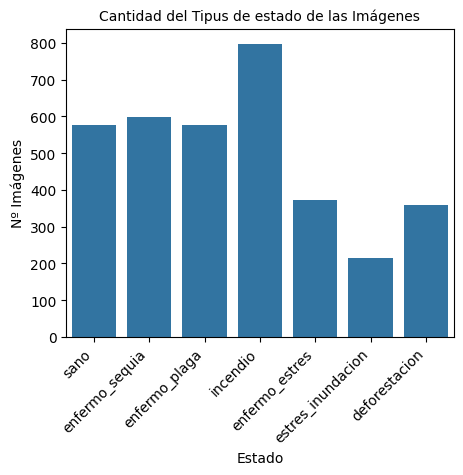

estado
deforestacion        359
enfermo_estres       373
enfermo_plaga        577
enfermo_sequia       598
estres_inundacion    214
incendio             798
sano                 577
dtype: int64 

Las etiquetas presentan un cierto desbalanceo, ya que mientras la clase mayoritaria tiene 798 muestras, la clase minoritaria solo tiene 214.


In [7]:
print("-----------------------------")
print("---- ENTENDER EL DATASET ----")
print("-----------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")
nom_target = df.columns[1]
target = df[nom_target]
valors_unics_target = target.sort_values().unique()
print("El target de nuestro Dataset es '" + nom_target + "', el cual tiene " + str(len(valors_unics_target)) + " categorias diferentes --> " + str(valors_unics_target))
 
"Segon punt"
print("\nSEGUNDO PUNTO:") 
atributs = [col for col in df.columns if col != 'label']
print("Existen " + str(len(atributs)) + f" atributos en nuestro Dataset. Estos incluyen identificadores, coordenadas y bandas espectrales (desde {atributs[0]} hasta {atributs[-1]}).")
 
"Tercer punt"
print("\nTERCER PUNTO:") 
print(df.dtypes)
print("\nPodemos ver que todos los atributos a excepción del identificador y el target son numéricos (float64). En cambio, el tarjet y el identificador son de tipo objeto, no obstante, podemos decire también que solo el tarjet es categórico.")

"Quart punt"
print("\nCUARTO PUNTO:") 
print(df.isnull().sum())
print("\nPodemos observar que se ven valores NaNs, por tanto tenemos una cantidad de " + str(df.isna().sum().sum()) + " valores NaNs")

"Cinquè punt"
print("\nQUINTO PUNTO:")  
plt.figure(figsize=(5, 4))
plt.ylabel("Nº Imágenes",fontsize=10)
plt.xlabel("Estado",fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.title("Cantidad del Tipus de estado de las Imágenes",fontsize=10)
sns.countplot(x='estado', data=df)
plt.show()
l = df.groupby(['estado']).size()
print(l,"\n")
 
print("Las etiquetas presentan un cierto desbalanceo, ya que mientras la clase mayoritaria tiene 798 muestras, la clase minoritaria solo tiene 214.")
 


------------------------------
---- ANÁLISIS UNIVARIANTE ----
------------------------------

PRIMER PUNTO:
              count          mean          std         min           25%  \
red_mean     3496.0  12267.349002  5254.894099    0.000000   8793.958008   
red_std      3496.0   2162.178709  2137.031475    0.000000    775.834015   
green_mean   3496.0  11923.953098  4864.796293    0.000000   9139.724121   
green_std    3496.0   1960.085715  2133.808779    0.000000    567.780869   
blue_mean    3496.0  10697.038061  4911.667203    0.000000   8200.262695   
blue_std     3496.0   1953.766644  2363.286454    0.000000    419.105545   
nir08_mean   3496.0  18430.349649  5235.878407    0.000000  15929.904297   
nir08_std    3496.0   2667.318937  2150.028702    0.000000   1132.616272   
swir16_mean  3496.0  15641.955384  5035.793662    0.000000  12464.194092   
swir16_std   3496.0   2496.168461  1857.602646    0.000000   1198.778931   
swir22_mean  3496.0  13015.781835  4456.636680    0.000

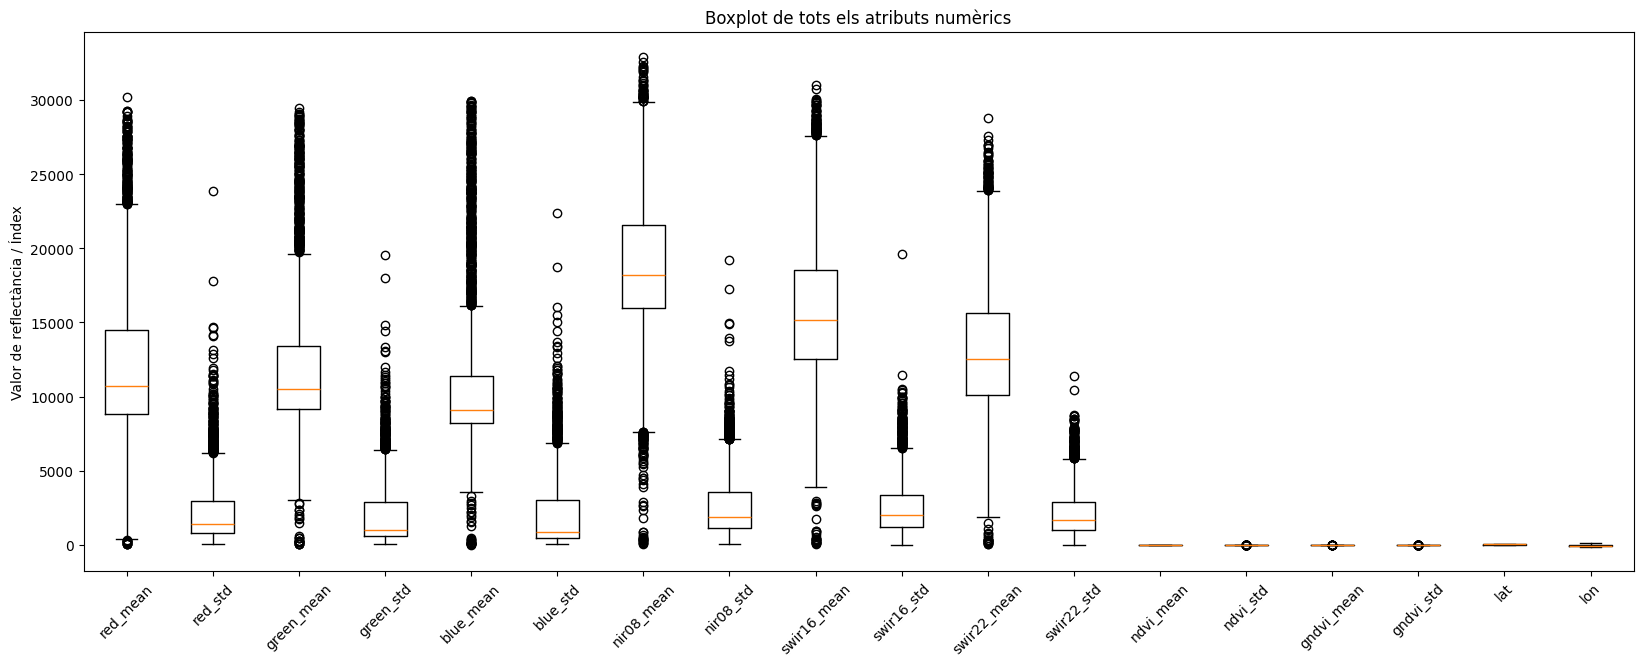

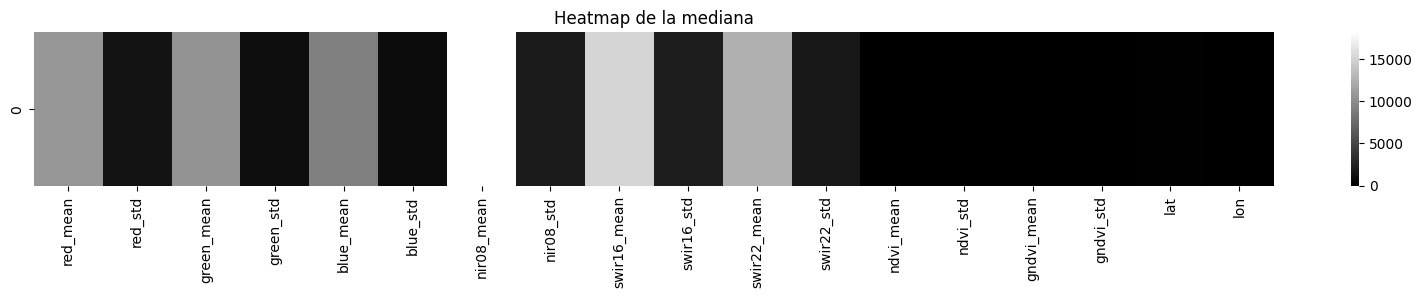

Hay valores fuera de rango o datos nulos que requieren limpieza.

TERCER PUNTO:
En nuestro Dataset, los atributos presentan escalas muy diversas (hasta 30.000). Por este motivo, trabajar con estas magnitudes puede dificultar el aprendizaje del modelo. 
Además, se aplica una normalización MinMaxScaler, que ajusta todos los valores estrictamente al intervalo [0, 1] basándose en los mínimos y máximos reales de cada columna.
Rang real abans de l'escalat: -123.39931113693852 - 32947.02734375
Rang després de l'escalat: 0.0 - 1.0000000000000002


In [15]:
print("\n------------------------------")
print("---- ANÁLISIS UNIVARIANTE ----")
print("------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")  

describe_pixels = df.describe().T
print(describe_pixels)
print("La distribución de las variables espectrales presenta una asimetría positiva. Esto se observa porque los valores de la media son superiores a la mediana (50%), lo que indica una mayor concentración de datos en valores bajos y medios, con la presencia de valores extremos (máximos) que desplazan el promedio hacia la derecha.")

"Segon punt"
print("\nSEGUNDO PUNTO:")   

df_numeric = df.select_dtypes(include=['number']) 
# Eliminar filas NaNs
df_plot = df_numeric.dropna() 
plt.figure(figsize=(20, 7)) 
plt.boxplot([df_plot[col] for col in df_plot.columns], tick_labels=df_plot.columns)

plt.title("Boxplot de tots els atributs numèrics")
plt.xticks(rotation=45) 
plt.ylabel("Valor de reflectància / Índex")
plt.show() 

df_num = df.select_dtypes(include=['number'])
medians = df_num.median().to_frame().T 
plt.figure(figsize=(20,2))
sns.heatmap(medians, cmap="gray")
plt.title("Heatmap de la mediana")
plt.show()

atributs_fora_rang = (df_num.min().min() < -1) or (df_num.max().max() > 65535)
label_con_problemas = df['estado'].isnull().any()

if not atributs_fora_rang and not label_con_problemas:
    print("Los datos están dentro de los rangos lógicos de satélite.")
    print("Sin embargo, SÍ hay valores atípicos (outliers) como vimos en el Boxplot.")
else:
    print("Hay valores fuera de rango o datos nulos que requieren limpieza.")

"Tercer punt"
print("\nTERCER PUNTO:")  
print("En nuestro Dataset, los atributos presentan escalas muy diversas (hasta 30.000). Por este motivo, trabajar con estas magnitudes puede dificultar el aprendizaje del modelo. ")
print("Además, se aplica una normalización MinMaxScaler, que ajusta todos los valores estrictamente al intervalo [0, 1] basándose en los mínimos y máximos reales de cada columna.")

X = df.select_dtypes(include=['number']).copy()
X = X.fillna(X.median())
y = df['estado'] 

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Rang real abans de l'escalat: {X.values.min()} - {X.values.max()}")
print(f"Rang després de l'escalat: {X_scaled.min()} - {X_scaled.max()}")


--------------------------------
---- RELACIÓN CON EL TARGET ----
--------------------------------

Cada banda espectral mide la reflectancia del terreno. Los patrones varían según el estado del campo (sano, incendio, plaga, etc.).

GROUPBY (Medias por estado):


,red_mean,red_std,green_mean,green_std,blue_mean,blue_std,nir08_mean,nir08_std,swir16_mean,swir16_std,swir22_mean,swir22_std,ndvi_mean,ndvi_std,gndvi_mean,gndvi_std,lat,lon
label,,,,,,,,,,,,,,,,,,
deforestacion,0.468041,0.122542,0.482212,0.137652,0.451010,0.128955,0.642705,0.137951,0.532579,0.131837,0.447749,0.160506,0.496487,0.255381,0.543596,0.229627,0.304196,0.510555
enfermo_estres,0.605808,0.093522,0.539169,0.095723,0.443163,0.080528,0.673819,0.108107,0.754914,0.123630,0.702076,0.207241,0.252271,0.136673,0.430027,0.136496,0.760321,0.291434
enfermo_plaga,0.344139,0.131392,0.351443,0.152182,0.314411,0.133103,0.499919,0.203327,0.424527,0.174593,0.380905,0.251513,0.513465,0.286096,0.561865,0.283449,0.911630,0.303807
enfermo_sequia,0.429735,0.090634,0.422806,0.101860,0.373745,0.088714,0.535101,0.127019,0.502192,0.123417,0.474158,0.183823,0.360405,0.137945,0.451141,0.147779,0.302785,0.555991
estres_inundacion,0.480374,0.068921,0.496476,0.082086,0.441076,0.082605,0.646386,0.086768,0.527505,0.065394,0.474821,0.095528,0.451870,0.168900,0.493609,0.172722,0.151967,0.875577
incendio,0.324944,0.065722,0.327269,0.070572,0.290578,0.057477,0.472467,0.126305,0.441783,0.122252,0.388960,0.170609,0.491121,0.177315,0.547681,0.174472,0.511611,0.117066
sano,0.358700,0.070340,0.378758,0.073504,0.328007,0.061917,0.606196,0.143890,0.484560,0.113386,0.421192,0.163666,0.623917,0.344600,0.649689,0.323036,0.734164,0.484433


Las medias muestran que ciertos estados del campo activan más unas bandas que otras. Por ejemplo, los campos sanos suelen tener un NDVI mucho más alto que los quemados.

BOXPLOT DEL NDVI POR ESTADO:


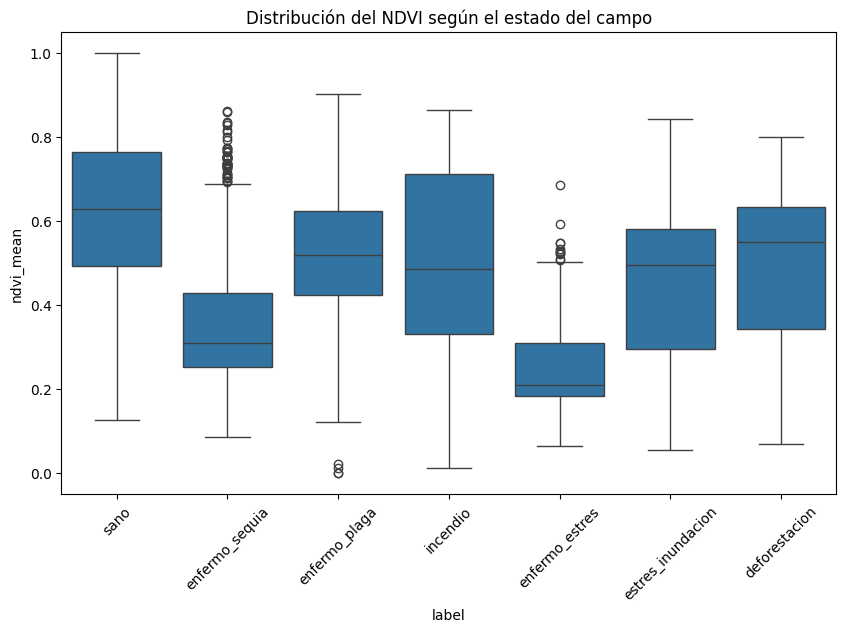

El boxplot confirma que el NDVI es un discriminador excelente para la clase 'sano' y 'enfermo_estres'. Sin embargo, existe un solapamiento significativo entre 'enfermo_plaga' y 'deforestacion', lo que implica que el modelo de clasificación dependerá de otras bandas espectrales para reducir la ambigüedad entre estos estados.

BARPLOT DE REFLECTANCIA TOTAL:


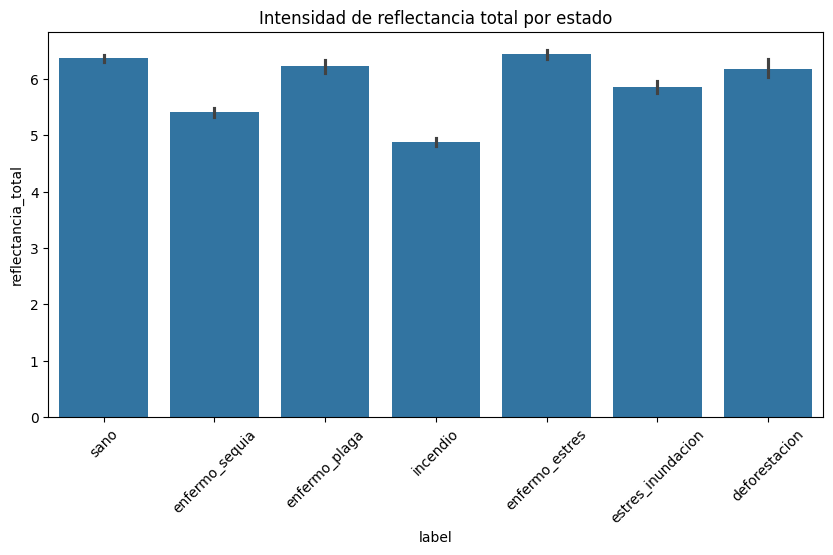

La energía total reflejada varía según el estado, por ejemplo, un suelo desnudo por incendio refleja la luz de forma muy distinta a una selva densa.

SCATTERPLOT (t-SNE):


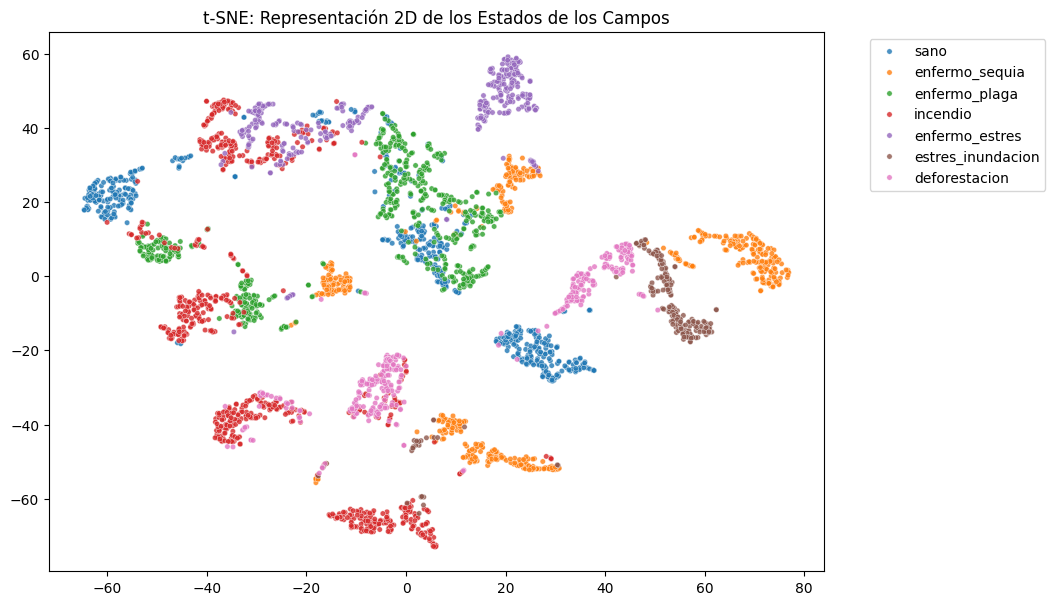

La representación t-SNE muestra una separación clara de clases críticas como 'incendio' y 'estres_inundacion', lo que garantiza una alta precisión en su detección. No obstante, el solapamiento visible entre 'sano' y 'enfermo_plaga' sugiere que el clasificador necesitará prestar atención a pequeñas variaciones en las bandas del infrarrojo para no confundir cultivos sanos con aquellos que están empezando a sufrir una plaga.
La fragmentación de algunas clases (como el rojo o el naranja) en varios clústeres indica que dentro de una misma categoría existe variabilidad interna. Esto puede deberse a diferentes estados de progresión del daño o a las diferencias en el tipo de cultivo afectado, lo que permitirá al modelo aprender patrones más complejos y específicos.


In [21]:
print("\n--------------------------------")
print("---- RELACIÓN CON EL TARGET ----")
print("--------------------------------\n")

df_analysis = pd.DataFrame(X_scaled, columns=X.columns)
df_analysis["label"] = y.values

print("Cada banda espectral mide la reflectancia del terreno. Los patrones varían según el estado del campo (sano, incendio, plaga, etc.).")

print("\nGROUPBY (Medias por estado):")
display(df_analysis.groupby("label").mean())
print("Las medias muestran que ciertos estados del campo activan más unas bandas que otras. Por ejemplo, los campos sanos suelen tener un NDVI mucho más alto que los quemados.")

print("\nBOXPLOT DEL NDVI POR ESTADO:")
plt.figure(figsize=(10,6))
sns.boxplot(x="label", y="ndvi_mean", data=df_analysis)
plt.xticks(rotation=45)
plt.title("Distribución del NDVI según el estado del campo")
plt.show()
print("El boxplot confirma que el NDVI es un discriminador excelente para la clase 'sano' y 'enfermo_estres'. Sin embargo, existe un solapamiento significativo entre 'enfermo_plaga' y 'deforestacion', lo que implica que el modelo de clasificación dependerá de otras bandas espectrales para reducir la ambigüedad entre estos estados.")

print("\nBARPLOT DE REFLECTANCIA TOTAL:") 
df_analysis["reflectancia_total"] = df_analysis.drop("label", axis=1).sum(axis=1)
plt.figure(figsize=(10,5))
sns.barplot(x="label", y="reflectancia_total", data=df_analysis)
plt.xticks(rotation=45)
plt.title("Intensidad de reflectancia total por estado")
plt.show()
print("La energía total reflejada varía según el estado, por ejemplo, un suelo desnudo por incendio refleja la luz de forma muy distinta a una selva densa.")

print("\nSCATTERPLOT (t-SNE):") 
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords_tsne = tsne.fit_transform(X_scaled) 

plt.figure(figsize=(10,7))
sns.scatterplot(x=coords_tsne[:,0], y=coords_tsne[:,1], hue=df_analysis["label"], palette="tab10", s=15, alpha=0.8)
plt.title("t-SNE: Representación 2D de los Estados de los Campos")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("La representación t-SNE muestra una separación clara de clases críticas como 'incendio' y 'estres_inundacion', lo que garantiza una alta precisión en su detección. No obstante, el solapamiento visible entre 'sano' y 'enfermo_plaga' sugiere que el clasificador necesitará prestar atención a pequeñas variaciones en las bandas del infrarrojo para no confundir cultivos sanos con aquellos que están empezando a sufrir una plaga.")
print("La fragmentación de algunas clases (como el rojo o el naranja) en varios clústeres indica que dentro de una misma categoría existe variabilidad interna. Esto puede deberse a diferentes estados de progresión del daño o a las diferencias en el tipo de cultivo afectado, lo que permitirá al modelo aprender patrones más complejos y específicos.")



---------------------------------
---- ANÁLISIS DE CORRELACIÓN ----
---------------------------------

PRIMER PUNTO:


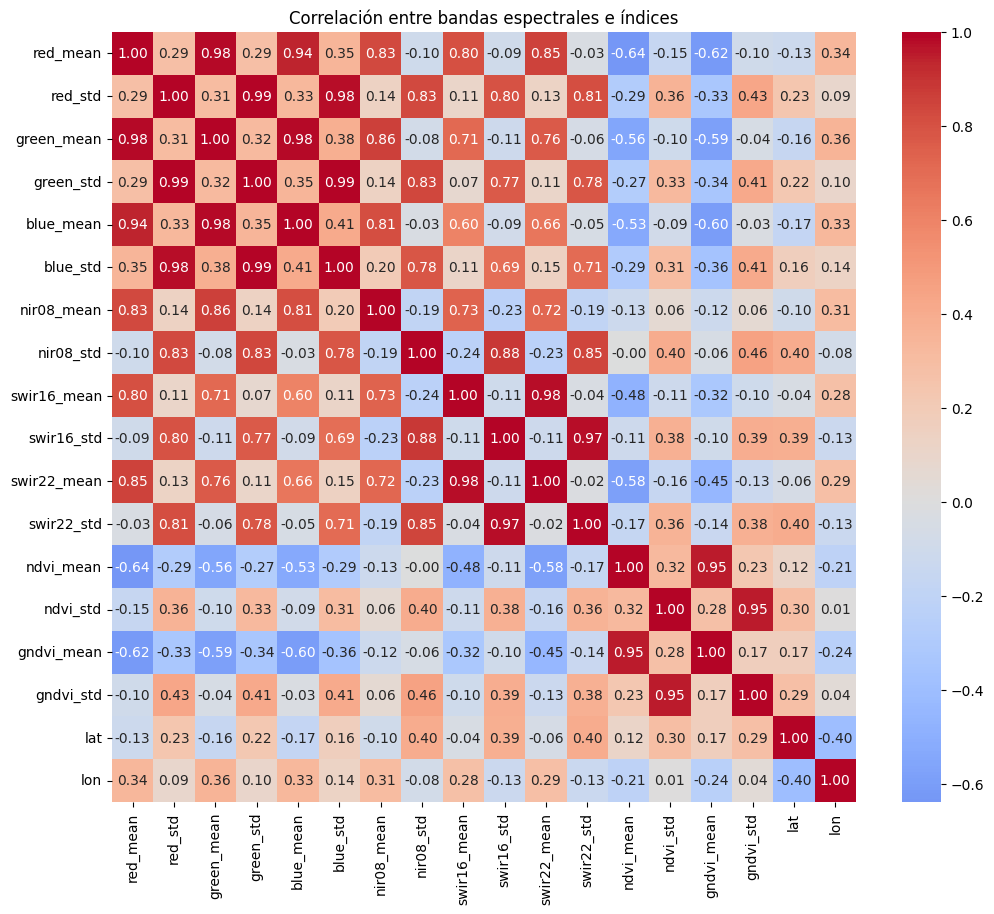

El mapa de correlación confirma una alta redundancia entre las bandas visibles y entre las métricas de desviación estándar. Sin embargo, destaca la correlación negativa entre el NDVI y las bandas visibles, lo cual es biológicamente coherente con la absorción de luz por parte de la clorofila. Esto sugiere que el modelo podrá beneficiarse de la reducción de dimensiones, ya que muchas variables aportan información muy similar.

SEGUNDO PUNTO:
El mapa de correlación confirma que existen atributos redundantes, especialmente entre las desviaciones estándar (std) y sus medias.


,Categoría,Número de atributos
0,Alta variabilidad,15
1,Baja variabilidad,3


Sin embargo, la tabla de variabilidad muestra que la gran mayoría de las bandas (83%) cambian de valor entre campos, lo que significa que los sensores están captando detalles reales del terreno en todo momento. Esto es una ventaja frente a otros datasets, ya que aquí casi no existen 'puntos muertos' o valores en cero que no aporten nada.


In [26]:
print("\n---------------------------------")
print("---- ANÁLISIS DE CORRELACIÓN ----")
print("---------------------------------\n")
  
"Primer punt"
print("PRIMER PUNTO:")    
corr = X.corr() 
plt.figure(figsize=(12,10)) 
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlación entre bandas espectrales e índices")
plt.show()

print("El mapa de correlación confirma una alta redundancia entre las bandas visibles y entre las métricas de desviación estándar. Sin embargo, destaca la correlación negativa entre el NDVI y las bandas visibles, lo cual es biológicamente coherente con la absorción de luz por parte de la clorofila. Esto sugiere que el modelo podrá beneficiarse de la reducción de dimensiones, ya que muchas variables aportan información muy similar.")

"Segon punt"
print("\nSEGUNDO PUNTO:")    
print("El mapa de correlación confirma que existen atributos redundantes, especialmente entre las desviaciones estándar (std) y sus medias.")

variabilidad = X.std()
resum_var = pd.DataFrame({
    "Categoría": ["Alta variabilidad", "Baja variabilidad"],
    "Número de atributos": [(variabilidad > 0.1).sum(), (variabilidad <= 0.1).sum()]
}) 
display(resum_var)
print("Sin embargo, la tabla de variabilidad muestra que la gran mayoría de las bandas (83%) cambian de valor entre campos, lo que significa que los sensores están captando detalles reales del terreno en todo momento. Esto es una ventaja frente a otros datasets, ya que aquí casi no existen 'puntos muertos' o valores en cero que no aporten nada.")
